# Semi-Automatic Mask Generation via Watershed

This notebook generates the binary ground-truth masks used for training the segmentation model. Since the MVTec dataset provides no segmentation masks, they are created here using a pipeline (Otsu thresholding → morphological cleanup → distance transform → watershed), with optional CLAHE contrast enhancement and gradient-based watershed input.

The optimal watershed parameters vary from image to image, so masks are generated iteratively:

1. Set the parameters (`current_params`) and run the algorithm on all remaining images in the list. Inspect the resulting masks and overlays in the plot.
2. Enter the indices of the images whose masks look good (`good_indices`). These are moved to the final results and removed from the list.
3. Repeat steps 1–2 with adjusted parameters until every image has an accepted mask.
4. Collect all accepted masks and download them.

Because the masks are produced this way rather than by manual annotation, they may contain small inaccuracies, especially around fine boundaries such as screw threads.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# list of indices of images to load
images = []
indices = [9, 11, 27, 32, 44, 50, 75, 91, 112, 121, 126]

# iterate over the indices and load the corresponding images
for i in indices:
    img = cv.imread(f"/data/home/lec42675/cv-segmentation/pill_images/{i:05d}.png")
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    images.append(img)

print(f"{len(images)} Bilder.")

11 Bilder bereit.


In [ ]:
# function to display images in a grid
def show_images(images, cols=4, titles=None):
    if not images:
        return
    n = len(images)
    # calculate the number of rows needed for the grid
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 5, rows * 5))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if titles and i < len(titles):
            plt.title(titles[i])

        # set colormap to gray for grayscale images
        cmap = "gray" if len(img.shape) == 2 else None

        # convert BGR to RGB for color images
        if len(img.shape) == 3:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        plt.imshow(img, cmap=cmap)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
def watershed_threshold_grad(
    images,
    indices=None,
    plot=False,
    T_mult=0.6,
    dil_it=2,
    dil_ks=3,
    bg_th=0.5,
    close_it=2,
    close_ks=5,
    ellipse_kernel=True,
    use_clahe=False,
    clahe_cliplimit=2.0,
    clahe_tilesize=(8, 8),
    use_gradient=True,
    use_watershed=True,
    fill_holes=False,
    border_alpha=0.4,
    border_color=(255, 0, 0),
):
    """
    segmentation using thresholding and watershed algorithm with optional gradient input for creting masks
    Parameters:
        images : List of grayscale input images.
        indices: List of indices for labeling plots. Defaults to None.
        plot : Whether to plot the masks and results. Defaults to False.
        T_mult : Multiplier for Otsu's threshold. Defaults to 0.6.
        dil_it : Number of iterations for dilation. Defaults to 2.
        dil_ks : Kernel size for dilation. Defaults to 3.
        bg_th : Threshold for sure foreground in distance transform. Defaults to 0.5.
        close_it : Number of iterations for closing operation. Defaults to 2.
        close_ks : Kernel size for closing operation. Defaults to 5.
        ellipse_kernel : Whether to use elliptical kernel for morphological operations. Defaults to True.
        use_clahe : Whether to apply CLAHE preprocessing. Defaults to False.
        clahe_cliplimit: Clip limit for CLAHE. Defaults to 2.0.
        clahe_tilesize : Tile size for CLAHE. Defaults to (8, 8).
        use_gradient : Whether to use gradient as input for watershed. Defaults to True.
        use_watershed : Whether to apply watershed algorithm. Defaults to True.
        fill_holes : Whether to fill holes in the detected object mask. Defaults to False.
        border_alpha : Alpha value for blending border color in result image. Defaults to 0.4.
        border_color : Color for borders in result image. Defaults to (255, 0, 0).
    """
    masks = []
    results = []

    if indices is None:
        indices = list(range(len(images)))

    for img, real_idx in zip(images, indices):
        img_orig = img.copy()

        # use clahe preprocessing for better contrast
        if use_clahe:
            # clipLimit is the threshold for contrast limiting, and tileGridSize is the size of the grid for histogram equalization.
            clahe = cv.createCLAHE(
                clipLimit=clahe_cliplimit, tileGridSize=clahe_tilesize
            )
            img = clahe.apply(img)

        # otsu thresholding to find initial threshold
        T_otsu, _ = cv.threshold(img, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
        T = int(T_otsu * T_mult)

        # create binary mask using the threshold
        mask = cv.threshold(img, T, 255, cv.THRESH_BINARY_INV)[1]

        # option to use elliptical kernel for morphological operations, else square kernel
        if ellipse_kernel:
            kernel_close = cv.getStructuringElement(
                cv.MORPH_ELLIPSE, (close_ks, close_ks)
            )
        else:
            kernel_close = np.ones((close_ks, close_ks), np.uint8)

        # closes small holes inside the foreground objects (Closing operation)
        mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel_close, iterations=close_it)

        # removes small noise from the foreground (Opening operation)
        mask = cv.morphologyEx(
            mask, cv.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1
        )

        # optionally fill holes in the mask
        if fill_holes:
            # find contours of the mask
            contours, _ = cv.findContours(
                mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE
            )
            # fill the contours in the mask with white (255) to fill holes
            cv.drawContours(mask, contours, -1, 255, cv.FILLED)

        # Convert original grayscale image to BGR for visualization
        img_color = cv.cvtColor(img_orig, cv.COLOR_GRAY2BGR)
        result = img_color.copy()

        # if watershed is to be used
        if use_watershed:
            # Sure Background: area that is sure background
            # we dilate the mask to get sure background area

            # choose kernel shape
            if ellipse_kernel:
                # use elliptical kernel
                kernel_dil = cv.getStructuringElement(
                    cv.MORPH_ELLIPSE, (dil_ks, dil_ks)
                )
            else:
                # use square kernel
                kernel_dil = np.ones((dil_ks, dil_ks), np.uint8)

            sure_bg = cv.dilate(mask, kernel_dil, iterations=dil_it)

            # Sure Foreground: area that is sure object (center of the object)
            # use distance transform and thresholding to get sure foreground area
            dist = cv.distanceTransform(mask, cv.DIST_L2, 5)
            _, sure_fg = cv.threshold(dist, bg_th * dist.max(), 255, 0)
            sure_fg = np.uint8(sure_fg)

            # Unknown region: area which is neither sure background nor sure foreground
            unknown = cv.subtract(sure_bg, sure_fg)

            # create markers for watershed
            ret, markers = cv.connectedComponents(
                sure_fg
            )  # connected components labeling
            markers = markers + 1
            markers[unknown == 255] = 0

            # optionally use gradient magnitude as input for watershed
            if use_gradient:
                # calculate gradient magnitude using Sobel operator
                grad_x = cv.Sobel(img, cv.CV_32F, 1, 0, ksize=3)
                grad_y = cv.Sobel(img, cv.CV_32F, 0, 1, ksize=3)
                grad_mag = cv.magnitude(grad_x, grad_y)
                # normalize the gradient magnitude to 0-255 and convert to uint8
                grad_mag = cv.normalize(grad_mag, None, 0, 255, cv.NORM_MINMAX).astype(
                    np.uint8
                )
                # convert gradient magnitude to BGR for watershed input
                ws_input = cv.cvtColor(grad_mag, cv.COLOR_GRAY2BGR)
            else:
                ws_input = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

            # apply watershed algorithm
            markers = cv.watershed(ws_input, markers)

            # resulting binary mask
            # Everything with marker > 1 is object. We set it to 255 (white).
            binary_mask = np.zeros_like(mask)
            binary_mask[markers > 1] = 255

            # Draw overlay (borders in color), to visualize the detected object boundaries
            border = markers == -1
            result[border] = border_color

        # no watershed --> just use the mask from thresholding and morphological operations
        else:
            binary_mask = mask

            # Draw overlay (borders in color)
            obj_mask = binary_mask == 255
            result[obj_mask] = (
                (1 - border_alpha) * result[obj_mask]
                + border_alpha * np.array(border_color)
            ).astype(np.uint8)

        masks.append(binary_mask)
        results.append(result)

    # plot masks and results if requested
    if plot:
        show_images(masks, cols=4, titles=[f"Mask {i}" for i in indices])
        show_images(results, cols=4, titles=[f"Result {i}" for i in indices])

    return masks, results

In [ ]:
# to store final results {index: (mask, result)}
final_results = {}

# list of indices that still need to be processed
todo_indices = list(range(len(images)))

# Temporary storage for the current attempt
current_batch_results = {}

print("Alle Bilder sind in der Todo-Liste.")

Workflow gestartet. Alle Bilder sind in der Todo-Liste.


Verarbeite Rest: 11 Bilder...


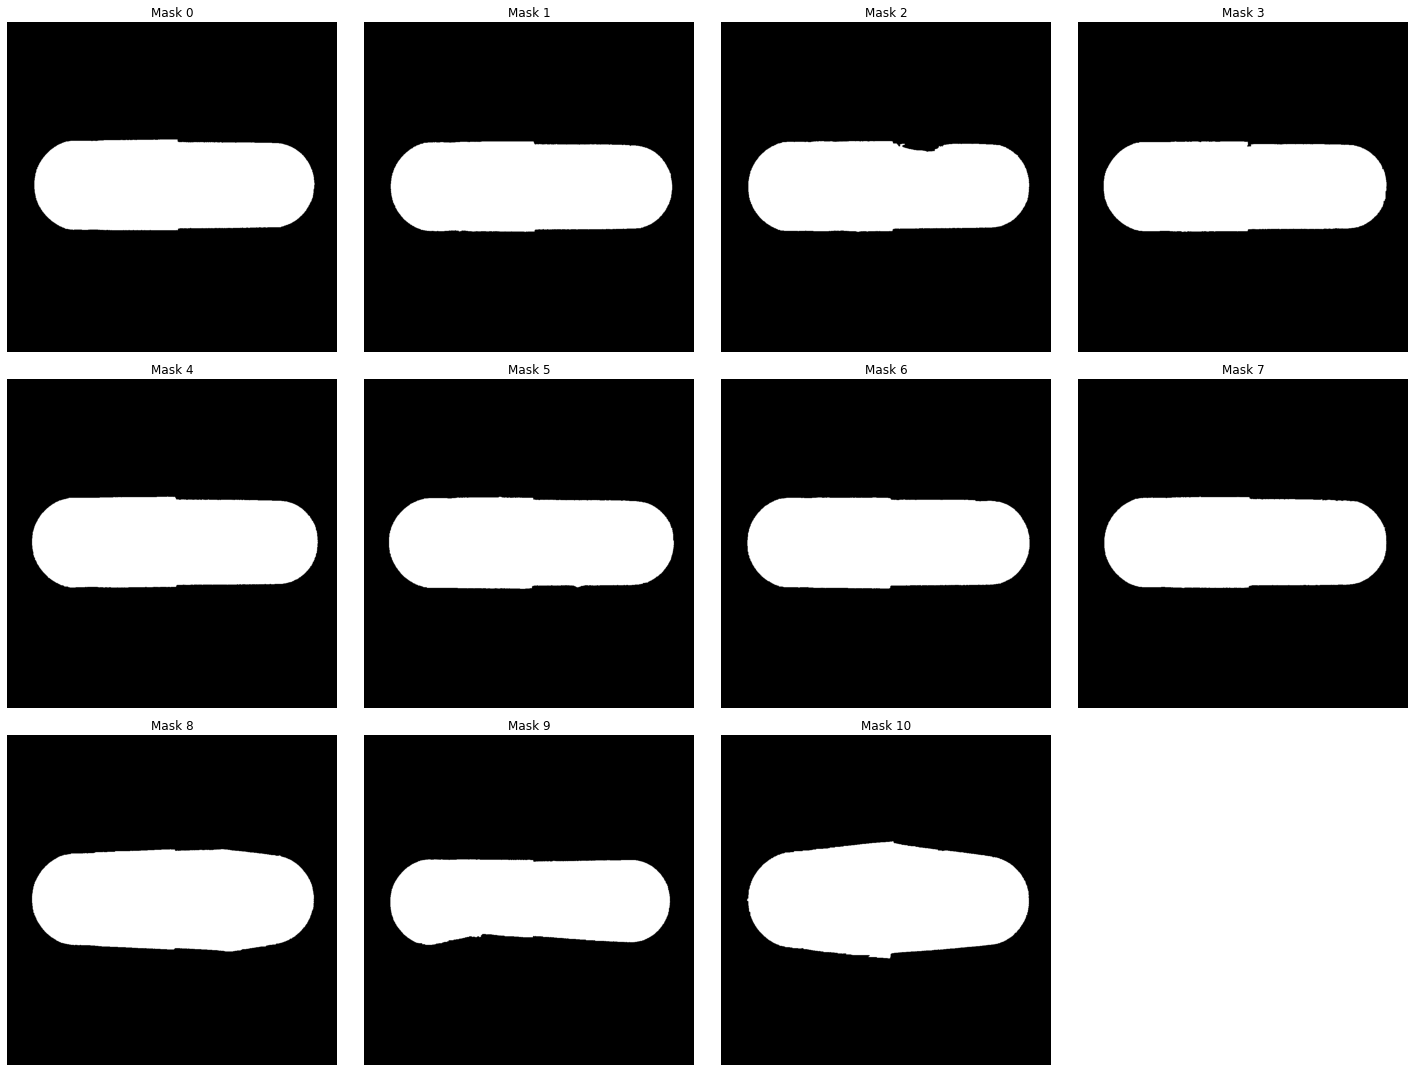

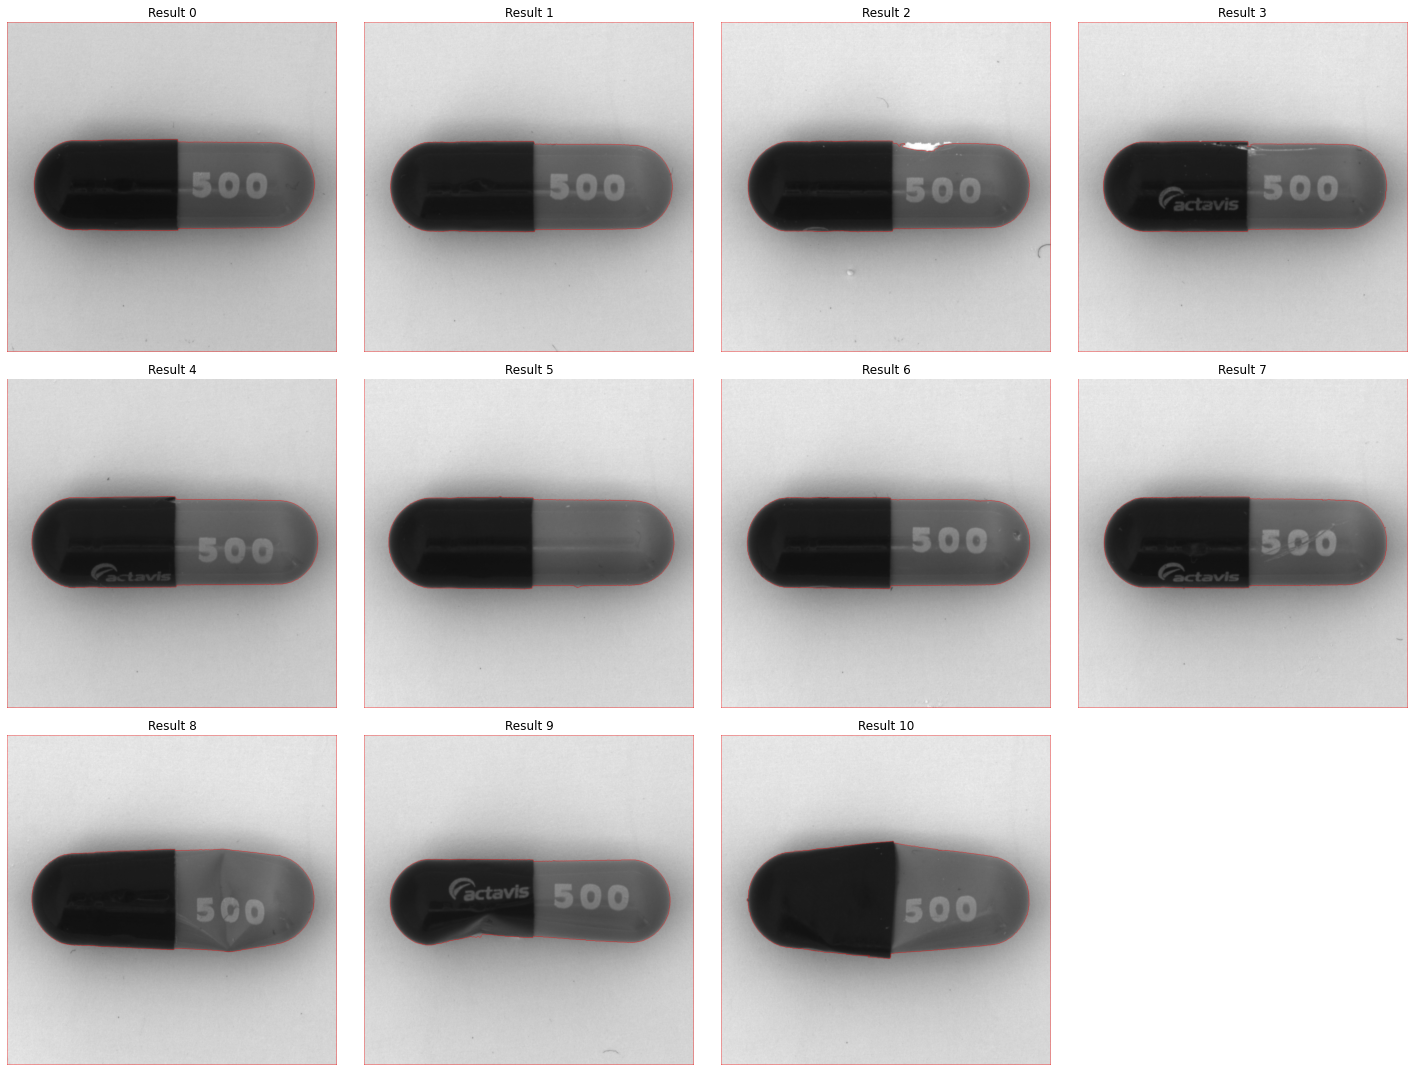

In [ ]:
# choose parameters for current run (they are alot)

current_params = {
    "T_mult": 1,
    "dil_it": 1,
    "dil_ks": 4,
    "bg_th": 0.1,
    "close_it": 0,
    "close_ks": 1,
    "ellipse_kernel": False,
    "use_clahe": False,
    "clahe_cliplimit": 0.1,
    "clahe_tilesize": (10, 10),
    "use_gradient": False,
    "use_watershed": True,
    "border_alpha": 0.5,
    "border_color": (0, 0, 255),
    "fill_holes": True,
}


if not todo_indices:
    print("Keine Bilder mehr übrig.")
else:
    print(f"Verarbeite Rest: {len(todo_indices)} Bilder...")

    # subset of images to process
    subset_images = [images[i] for i in todo_indices]

    # run algorithm
    masks, overlays = watershed_threshold_grad(
        subset_images,
        indices=todo_indices,
        plot=True,
        **current_params,
    )

    # save results temporarily for selection
    current_batch_results = {}
    for idx, mask, res in zip(todo_indices, masks, overlays):
        current_batch_results[idx] = (mask, res)

In [ ]:
# write down the indices of the images that looked good
good_indices = [10]

# save selected good results and update todo list
count = 0
for idx in good_indices:
    if idx in current_batch_results:
        # store in final results
        final_results[idx] = current_batch_results[idx]

        # delete from todo list
        if idx in todo_indices:
            todo_indices.remove(idx)
            count += 1
    else:
        print(f"Index {idx} ist nicht im aktuellen Batch oder schon erledigt.")

print(f"{count} Bilder gespeichert.")
print(f"noch übrig: {todo_indices}")

1 Bilder gespeichert.
noch übrig: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Fertig! 1 Masken gesammelt.


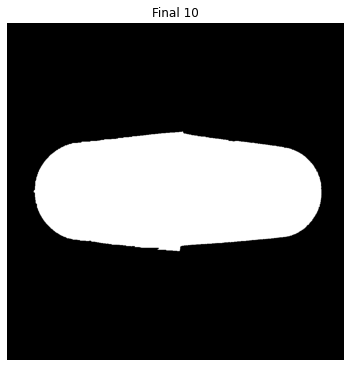

In [7]:
#  sort final results by index (0, 1, 2, 3...)
sorted_indices = sorted(final_results.keys())

# create final lists
final_masks_list = [final_results[i][0] for i in sorted_indices]
final_results_list = [final_results[i][1] for i in sorted_indices]

print(f"Fertig! {len(final_masks_list)} Masken gesammelt.")

# show final masks
show_images(final_masks_list, cols=4, titles=[f"Final {i}" for i in sorted_indices])

In [ ]:
# download final masks and images
path = "/data/home/lec42675/cv-segmentation/images/masks"
# os.makedirs("./Data/screw/masks", exist_ok=True)
path_img = "/data/home/lec42675/cv-segmentation/images"
for i, mask in zip(sorted_indices, final_masks_list):
    cv.imwrite(f"{path}/mask_{i+10:05d}.png", mask)
    cv.imwrite(f"{path_img}/{i+10:05d}.png", images[i])